<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana5/CuadraturaGaussiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
import sympy as sym

In [3]:
x = sym.Symbol('x',real='True')
F = sym.cos(x)**2
F

cos(x)**2

In [5]:
sym.integrate(F,(x,-1.,1.))

1.45464871341284

In [7]:
f = lambda x: np.cos(x)**2

In [8]:
W = np.array([1.,1.])
X = np.array([-1/np.sqrt(3),1/np.sqrt(3)])
I = np.sum(W*f(X))
I

np.float64(1.4041924619823274)

In [19]:
ROOTS,WEIGHTS = np.polynomial.legendre.leggauss(10)
ROOTS

array([-0.97390653, -0.86506337, -0.67940957, -0.43339539, -0.14887434,
        0.14887434,  0.43339539,  0.67940957,  0.86506337,  0.97390653])

In [20]:
WEIGHTS

array([0.06667134, 0.14945135, 0.21908636, 0.26926672, 0.29552422,
       0.29552422, 0.26926672, 0.21908636, 0.14945135, 0.06667134])

In [21]:
I = np.sum(WEIGHTS*f(ROOTS))
I

np.float64(1.4546487134128407)

In [22]:
sym.integrate(F,(x,-1.,1.))

1.45464871341284

In [23]:
sym.integrate(F,(x,0,sym.pi))

pi/2

In [ ]:
def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-14):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

In [ ]:


def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-12):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

def GetAllRoots(f, df, x, tolerancia_decimales=8, tol_unicidad=1e-9):

    Roots = []

    for x0 in x:

        root = GetNewtonMethod(f, df, x0)

        if root is not False:

            # Redondeamos
            croot = np.round(root, tolerancia_decimales)

            # Verificamos que no esté ya (con tolerancia)
            if not any(np.isclose(croot, r, atol=tol_unicidad) for r in Roots):
                Roots.append(croot)

    Roots = np.array(Roots)
    Roots.sort()

    return Roots

In [ ]:
x = sym.Symbol('x',Real=True)
F = sym.cos(10*x)*sym.exp(-0.9*x)
#F = x**3 - x**4 + 2*x**2 + 2*x + 1
F

exp(-0.9*x)*cos(10*x)

In [ ]:
DF = sym.diff(F,x)
DF

-10*exp(-0.9*x)*sin(10*x) - 0.9*exp(-0.9*x)*cos(10*x)

In [ ]:
# Funcion en numpy
Fn = sym.lambdify([x],F,'numpy')
DFn = sym.lambdify([x],DF,'numpy')

In [ ]:
xi = np.linspace(0.2,5,57,dtype=np.longdouble)
roots = GetAllRoots(Fn,DFn,xi)
roots

array([-0.15707963,  0.15707963,  0.4712389 ,  0.78539816,  1.09955743,
        1.41371669,  1.72787596,  2.04203522,  2.35619449,  2.67035376,
        2.98451302,  3.29867229,  3.61283155,  3.92699082,  4.24115008,
        4.55530935,  4.86946861], dtype=float128)

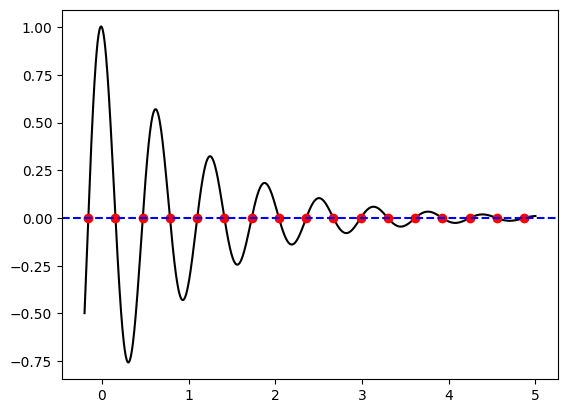

In [ ]:
xj = np.linspace(-0.2,5,1000,dtype=np.longdouble)
plt.plot(xj,Fn(xj),color='k')
plt.plot(roots,Fn(roots),'o',color='r')
plt.axhline(0,linestyle='--',color='b')
#plt.xscale('log')